In [21]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

In [22]:
# Reduced epochs for CPU efficiency; increased batch size for stability
EPOCHS = 5 
BATCH_SIZE = 128
LR = 0.001
WEIGHT_DECAY = 0.0001
SEED = 42

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

DATA_DIR = './data'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [23]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# CUDA/cuDNN seeds removed for CPU-only execution

In [24]:
# Use MPS (Metal Performance Shaders) for M1/M2/M3 Mac GPU acceleration
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f'PyTorch version : {torch.__version__}')
print(f'Using Device: {DEVICE}')

PyTorch version : 2.9.1
Using Device: mps


## Calculation
Computing the mean and standard deviations for faster processing by normalizing data.


In [25]:
raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
loader = DataLoader(raw_dataset, batch_size=1000, shuffle=False, num_workers=0)

channel_sum    = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
total_pixels   = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)
    channel_sum    += images.sum(dim=[0, 2])
    channel_sum_sq += (images ** 2).sum(dim=[0, 2])
    total_pixels   += batch_size * 32 * 32

mean = channel_sum / total_pixels
std  = torch.sqrt(channel_sum_sq / total_pixels - mean ** 2)

print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4914, 0.4822, 0.4465])
Std:  tensor([0.2470, 0.2435, 0.2616])


# Reducing Overfitting (Data Augmentatin)

We are basically adding artifical variance in the dataset

Quoting form the provided paper :

"The easiest and most common method to reduce overfitting on image data is to artificially enlarge
the dataset using label-preserving transformation"

Here ve have used in order:
- Random Clip
- Random Horizontal Flip
- Color jitter

In [42]:
MEAN = mean
STD = std

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

# Optimized for M1: num_workers=0 prevents memory pressure
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

/Users/pranishkoirala/Desktop/Pranishkkk/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


/var/folders/dc/06975tzs7wg0dd6xp4rdzbn00000gn/T/ipykernel_30006/2301372429.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)


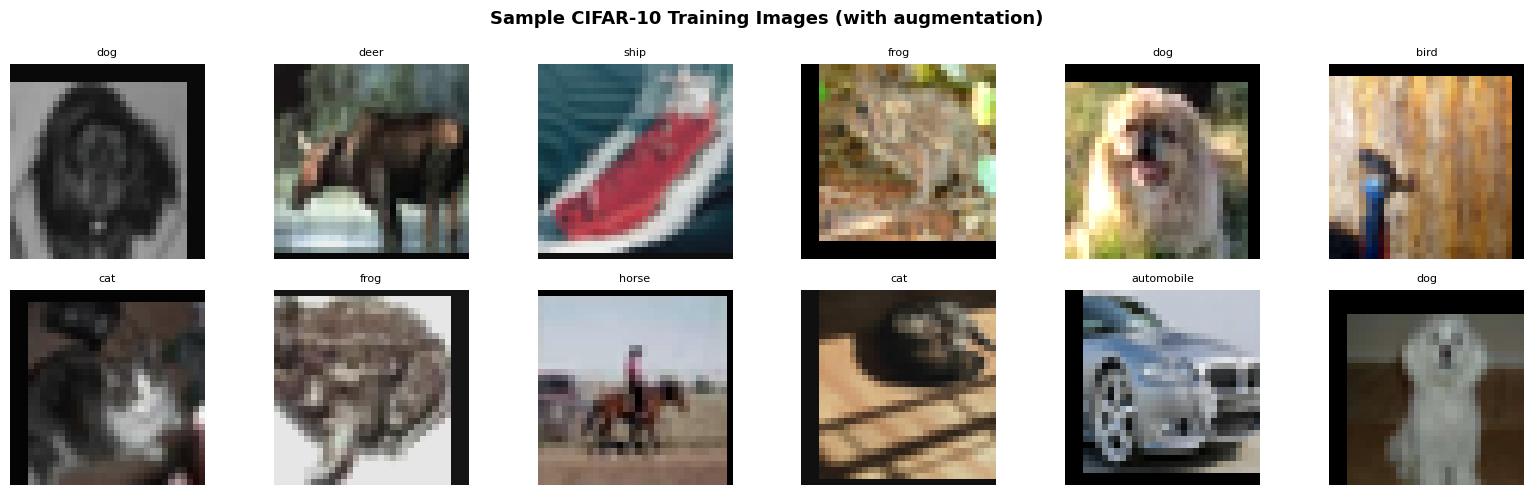

In [43]:
def imshow(img_tensor, title=None):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)
    plt.imshow(img)
    if title: plt.title(title, fontsize=8)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], CLASSES[labels[i]])
plt.suptitle('Sample CIFAR-10 Training Images (with augmentation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
class SimpleNN(nn.Module):
    def __init__(self, dropout_rate=0.4):
        """
        We are using 3*32*32 = 3072 features as input
        The output is 10 classes

        In simple NN we loose the spatial information since we flatten the image
        The BatchNormal is used to reduce computation time using the current batch
         - std dev - mean
        Droupout is used to prevent overfitting by cutting off impact of some neurons
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), # Flattening of spatial data occours here

            nn.Linear(3*32*32, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

In [45]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super().__init__()
        """
        Here We implement the AlexNet architecture for CIFAR-10 dataset
        We are using 3*32*32 2d images as input

        There are 8 layers in total
        There are 5 layers of convolution and 3 layers of fully connected
        2 max pool layer within the 5 Convolutional layers to reduce the size of the data
        This architecture is a copy of the AlexNet architecture as provided in the resource


        The output is 10 classes
        """

        # Convolutional Layer
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))

        # Fully Connected Layer
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

        self._init_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

In [46]:
class ConvBlock(nn.Module):
    """
    Basic Block for CNN
    Helper class for TinyVGG
    used instead of repeating the same code multiple times
    """
    def __init__(self, in_ch, out_ch, kernel=3, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class TinyVGG(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        """
        Tiny VGG implementation
        """

        self.block1 = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 32),
            nn.MaxPool2d(2, 2),#32 to 16
            nn.Dropout2d(dropout_rate),
        )
        self.block2 = nn.Sequential(
            ConvBlock(32, 64), ConvBlock(64, 64),
            nn.MaxPool2d(2, 2),# 16 to 8
            nn.Dropout2d(dropout_rate),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),# hence here 64x8x8
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

In [47]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = {
    'SimpleNN': SimpleNN(dropout_rate=0.4),
    'AlexNet':  AlexNetCIFAR(num_classes=10, dropout_rate=0.5),
    'TinyVGG':  TinyVGG(num_classes=10, dropout_rate=0.3),
}

for name, model in models.items():
    params = count_parameters(model)
    print(f'  {name:10s}: {params:>10,} parameters')

  SimpleNN  :  3,809,034 parameters
  AlexNet   :  7,175,754 parameters
  TinyVGG   :  1,117,354 parameters


In [48]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    return total_loss/total, 100.0*correct/total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += images.size(0)
    return total_loss/total, 100.0*correct/total

def train_model(model, name, train_loader, test_loader, device, epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}
    best_acc = 0.0
    start = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = eval_epoch(model, test_loader, criterion, device)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss); history['test_acc'].append(te_acc)
        if te_acc > best_acc:
            best_acc = te_acc
        if epoch % 5 == 0 or epoch == 1:
            print(f'  {name} Epoch {epoch}: Acc {te_acc:.2f}%')
    history['total_time'] = time.time() - start
    history['best_acc'] = best_acc
    return history

In [ ]:
histories = {}
for name, model in models.items():
    histories[name] = train_model(model, name, train_loader, test_loader, DEVICE)

  SimpleNN Epoch 1: Acc 39.97%
  SimpleNN Epoch 5: Acc 48.89%


In [ ]:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
def compute_all_metrics(model, loader, device, class_names=CLASSES):
    model.eval()
    all_preds, all_targets, all_outputs = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            all_outputs.append(out.cpu())
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_targets.extend(lbls.cpu().numpy())

    outputs_tensor = torch.cat(all_outputs)
    preds   = np.array(all_preds)
    targets = np.array(all_targets)

    return {
        'accuracy':  accuracy_score(targets, preds) * 100,
        'precision': precision_score(targets, preds, average='macro', zero_division=0) * 100,
        'recall':    recall_score(targets, preds, average='macro', zero_division=0) * 100,
        'f1':        f1_score(targets, preds, average='macro', zero_division=0) * 100,
        'cm':        confusion_matrix(targets, preds),
        'report':    classification_report(targets, preds, target_names=class_names, zero_division=0),
        'preds':     preds,
        'targets':   targets,
    }

all_metrics = {}
print('Computing test set metrics...')
for name, model in models.items():
    all_metrics[name] = compute_all_metrics(model, test_loader, DEVICE)
    m = all_metrics[name]
    print(f'\n  {name}: Acc={m["accuracy"]:.2f}%  P={m["precision"]:.2f}%  '
          f'R={m["recall"]:.2f}%  F1={m["f1"]:.2f}% ')

Computing test set metrics...

  SimpleNN: Acc=48.27%  P=47.75%  R=48.27%  F1=46.91% 

  AlexNet: Acc=79.28%  P=78.99%  R=79.28%  F1=78.86% 

  TinyVGG: Acc=55.96%  P=55.56%  R=55.96%  F1=54.77% 


In [ ]:
for name, m in all_metrics.items():
    print(f'\n{"-"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"-"*55}')
    print(m['report'])


-------------------------------------------------------
  Classification Report — SimpleNN
-------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.57      0.55      0.56      1000
  automobile       0.55      0.65      0.59      1000
        bird       0.40      0.25      0.31      1000
         cat       0.37      0.26      0.30      1000
        deer       0.50      0.28      0.36      1000
         dog       0.44      0.32      0.37      1000
        frog       0.43      0.65      0.52      1000
       horse       0.47      0.62      0.53      1000
        ship       0.59      0.64      0.61      1000
       truck       0.46      0.61      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.47     10000
weighted avg       0.48      0.48      0.47     10000


-------------------------------------------------------
  Classification Report — AlexNet
--

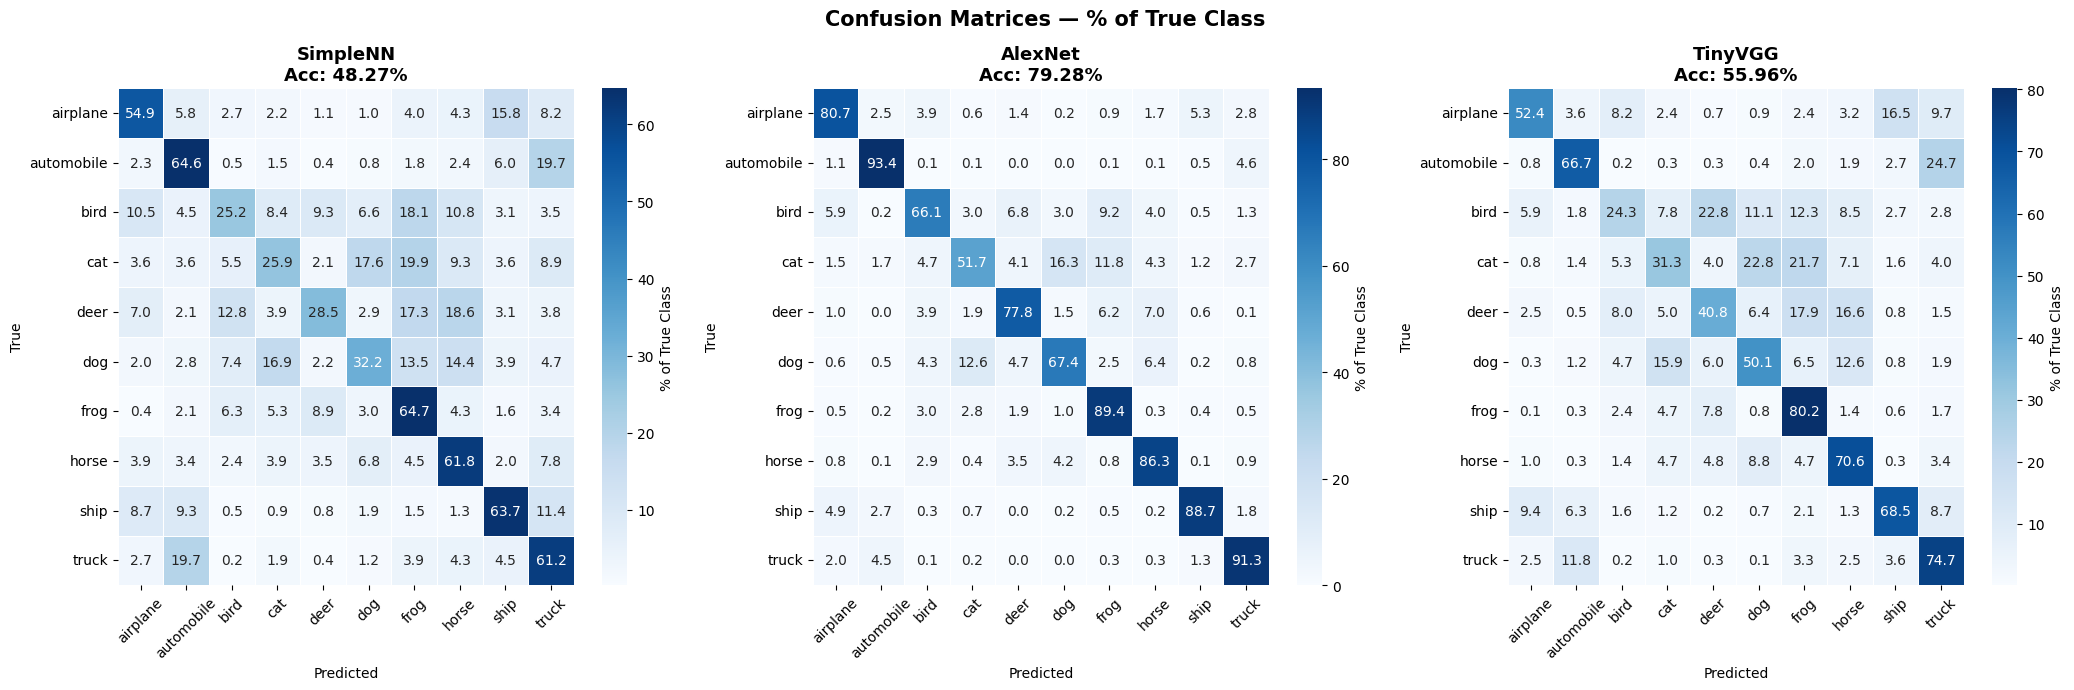

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, m) in zip(axes, all_metrics.items()):
    cm_pct = m['cm'].astype(float) / m['cm'].sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, ax=ax, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cbar_kws={'label': '% of True Class'}, linewidths=0.4)
    ax.set_title(f'{name}\nAcc: {m["accuracy"]:.2f}%', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — % of True Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
rows = []
for name in all_metrics:
    m = all_metrics[name]
    h = histories[name]
    rows.append({
        'Model':          name,
        'Accuracy (%)':   round(m['accuracy'],  2),
        'Precision (%)':  round(m['precision'], 2),
        'Recall (%)':     round(m['recall'],    2),
        'F1 (%)':         round(m['f1'],        2),
        'Params (K)':     round(count_parameters(models[name]) / 1000, 1),
        'Train Time (s)': round(h['total_time'], 1),
    })

df = pd.DataFrame(rows).set_index('Model')
print(df)

          Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Params (K)  \
Model                                                                   
SimpleNN         48.27          47.75       48.27   46.91      3809.0   
AlexNet          79.28          78.99       79.28   78.86      7175.8   
TinyVGG          55.96          55.56       55.96   54.77      1117.4   

          Train Time (s)  
Model                     
SimpleNN           357.7  
AlexNet           4338.5  
TinyVGG            521.0  


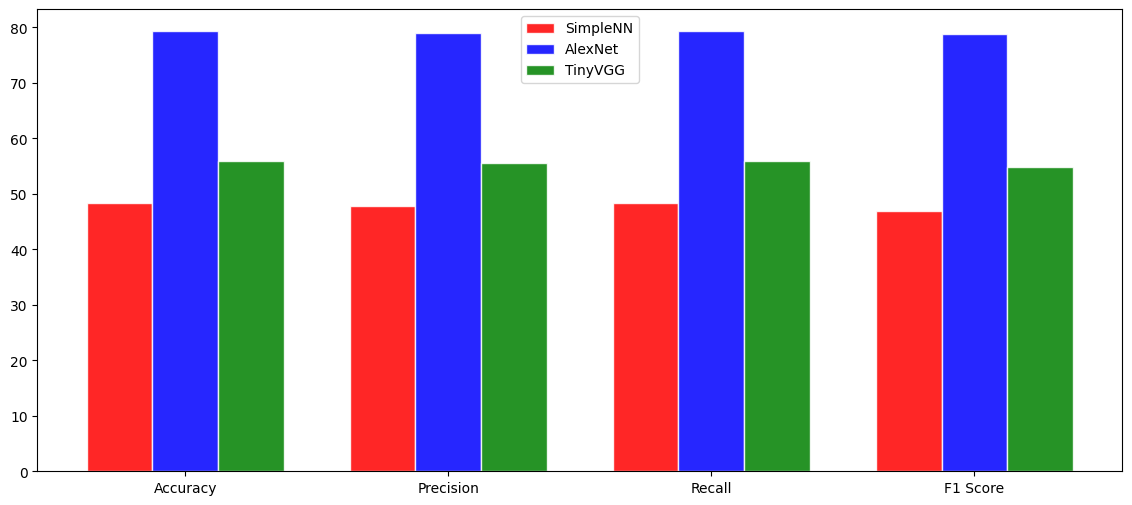

In [ ]:
metric_keys   = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
names  = list(all_metrics.keys())
x      = np.arange(len(metric_keys))
width  = 0.25
colors_list = ['red', 'blue', 'green']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(names, colors_list)):
    vals = [all_metrics[name].get(k, 0) for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width); ax.set_xticklabels(metric_labels)
ax.legend(); plt.show()



In deep learning, we usually start with something basic and move toward complexity to see if the "extra brain power" actually improves accuracy or just wastes time.
## The Lineup: Why These Three?
Model	The Role	The Logic
SimpleNN	The Baseline	To prove that a basic "flat" network (Fully Connected) sucks at images. It treats pixels like a list of numbers rather than a 2D picture.
AlexNet	The Legend	The 2012 "game changer." It uses Convolutional layers to "see" shapes, edges, and textures. It's the heavy hitter of the group.
TinyVGG	The Efficiency Expert	A modernized, slimmed-down version of the VGG architecture. It uses smaller filters (3×3) to get better results with fewer parameters.
### 1. SimpleNN (Multilayer Perceptron)

    Need: To establish a "floor" for performance.
    Advantages: Extremely fast to train; very few parameters; easy to understand.
    Disadvantages: It has no "spatial awareness." If you shift an image of a cat by 2 pixels, SimpleNN thinks it's a completely different object. It usually plateaus at very low accuracy for CIFAR-10.

### 2. AlexNet
    Need: To handle complex features using Convolutional Neural Networks (CNNs).
    Advantages: Uses ReLU activation and Dropout to prevent overfitting. It captures "high-level" features (like ears, wheels, or wings) much better than a SimpleNN.
    Disadvantages: It’s "heavy." It has large filters (11×11) in the first layer which are computationally expensive. On your M1, this is the one that will likely take the most memory.

### 3. TinyVGG
    Need: To show that deeper is often better than wider.
    Advantages: By stacking multiple 3×3 filters, it achieves the same "field of view" as AlexNet but with much more non-linearity (more chances to learn). It's very modular and typically the most accurate of the three.
    Disadvantages: Can be prone to "vanishing gradients" if it gets too deep, though "Tiny" versions usually avoid this.



### Conclusion
 
 As we were supposed to carry out 30 epochs for better accuracy but it could take more than a day to comute in my laptop so i reduced the epoch count by 5 such that it can be computed faster . Even after the 5 epoch  finish, we can likely see a trend that;

    SimpleNN will finish first but have the worst accuracy (likely under 40%).

    AlexNet will show a massive jump in accuracy but might feel "sluggish."

    TinyVGG should ideally be your "Goldilocks" model—highest accuracy with a relatively stable training time.

The ultimate lesson we understood is that  for images, Convolutions (AlexNet/VGG) win. Standard neural networks (SimpleNN) lose.